# The Executive Report - Flights Dataset
* Dataset: sns.load_dataset('flights') 
* Goal: Take raw historical flight data and polish it into a presentation-ready graphic.
* Themes & Contexts: Apply sns.set_style('whitegrid') to give it a clean background, and sns.set_context('talk') to automatically scale up the fonts for a presentation slide.
* Color Palettes: Pivot the dataset into a matrix (months vs. years) and plot a heatmap.
* Use sns.color_palette("Blues", as_cmap=True) so the colors intuitively map from light (few passengers) to dark (many passengers).
* Advanced Matplotlib Formatting: Plot a line chart of average passengers per year.
* Rotate the X-axis labels (years) by 45 degrees so they are perfectly legible.
* Use ax.set_ylim(0, 500) to force the Y-axis to start at zero instead of floating.
* Use ax.annotate() to draw an arrow pointing to the year 1960 with the text: "Introduction of Commercial Jets".

Exporting: Run plt.savefig('executive_flight_report.png', dpi=300, bbox_inches='tight') to save the final, high-resolution masterpiece to their computer.Explain each of the graphs in details(both Khmer and English)


In [26]:
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

df= sns.load_dataset('flights')
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


* Themes & Contexts: Apply sns.set_style('whitegrid') to give it a clean background, and sns.set_context('talk') to automatically scale up the fonts for a presentation slide.
* Color Palettes: Pivot the dataset into a matrix (months vs. years) and plot a heatmap.
* Use sns.color_palette("Blues", as_cmap=True) so the colors intuitively map from light (few passengers) to dark (many passengers).

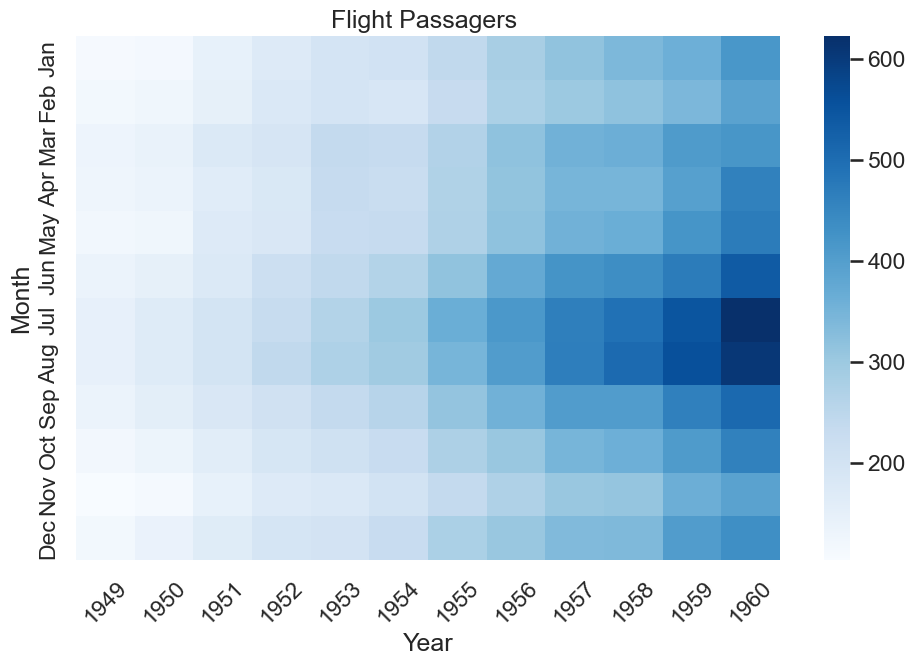

In [38]:
sns.set_style('whitegrid')
sns.set_context('talk')
flights_pivot = df.pivot(index= 'month', columns= 'year', values= 'passengers') 
plt.figure(figsize=(10,7))
sns.heatmap(data= flights_pivot, cmap=sns.color_palette("Blues", as_cmap=True))
plt.title("Flight Passagers ")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.ylabel("Month")
plt.tight_layout()
plt.show()

This graph shows that while air travel steadily grew every single year from 1949 to 1960, July and August consistently remained the busiest peak months due to summer vacations.

* Advanced Matplotlib Formatting: Plot a line chart of average passengers per year.
* Rotate the X-axis labels (years) by 45 degrees so they are perfectly legible.
* Use ax.set_ylim(0, 500) to force the Y-axis to start at zero instead of floating.
* Use ax.annotate() to draw an arrow pointing to the year 1960 with the text: "Introduction of Commercial Jets".


/var/folders/34/tcqt3fyx41z17xmtzkx9_6_r0000gn/T/ipykernel_57625/1346976505.py:9: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate("Introduction of\nCommerical Jets",


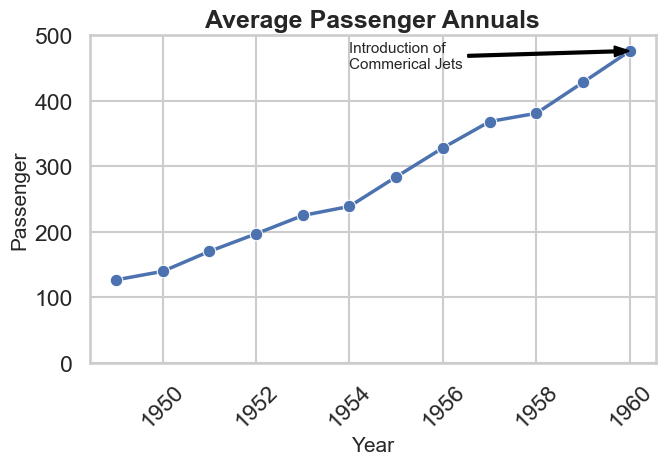

In [85]:
yearly_avg = df.groupby('year')['passengers'].mean().reset_index()
fix, ax =plt.subplots(figsize=(7,5))
sns.lineplot(data= yearly_avg, x= 'year', y= 'passengers', marker='o', linewidth= 2.5, ax=ax)
plt.title("Average Passenger Annuals", weight="bold")
plt.xlabel("Year", fontsize=15)
plt.xticks(rotation=45)
ax.set_ylim(0,500) 
plt.ylabel("Passenger", fontsize=15)
ax.annotate("Introduction of\nCommerical Jets",
            xy=(1960,yearly_avg.loc[yearly_avg['year'] == 1960,"passengers"].values[0]),
            xytext=(1954, 450),
            arrowprops=dict(facecolor='2c3e50', shrink= 0.008, color='black', width= 1.5, headwidth=7, headlength=10),
            fontsize=11
           )
plt.tight_layout()
plt.show()

This graph illustrates a clear, continuous upward trend in annual passenger averages, highlighted by a massive surge in 1960 driven by the introduction of commercial jet airliners.